# Cross-border legal interoperability visualizations — extended exploratory notebook

This notebook generates a full exploratory visualization workflow for a **directional, categorical, country-by-country legal interoperability matrix**.

The matrix is interpreted as:

- **Rows** = origin / exporting jurisdictions.
- **Columns** = destination / receiving jurisdictions.
- **Cells** = legal compatibility class for biomedical or neurodata transfer from row jurisdiction to column jurisdiction.

The notebook includes:

1. Directional compatibility matrix.
2. Per-country stacked distribution plot.
3. Import and export modal world maps.
4. Asymmetry matrix.
5. Directed network analysis.
6. Country legal-profile embedding using PCA.
7. Entropy / diversity profile and map.
8. Sankey / alluvial-style flow summary.
9. Region-aggregated block matrix.
10. Parallel-coordinate country profiles.
11. Row-normalized country-by-class heatmap.
12. Inequality / Lorenz-style analysis of average legal friction.

Self-transfers are excluded from all summary analyses unless otherwise stated.


## Setup

Place the Excel file in the same directory as this notebook, or change `DATA_FILE` below to the full path of the file.

The world-map sections require a country boundary file such as Natural Earth Admin 0 countries. If the file is not available, the notebook will still run the non-map analyses.


In [9]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
!pip install openpyxl

from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, TwoSlopeNorm
import matplotlib.patches as mpatches

DATA_FILE = Path("/Users/fp4834/Downloads/data-sharing-matrix.xlsx")

OUTDIR = Path("outputs")
OUTDIR.mkdir(exist_ok=True)

CATEGORY_ORDER = ["A1", "A2", "B", "C", "D", "E"]

CATEGORY_LABELS = [
    "A1 — directly enabled (same legal space)",
    "A2 — directly enabled (adequacy / high convergence)",
    "B — permissible with standard transfer tools (DTA)",
    "C — permissible but legally conditional / friction heavy",
    "D — restricted / difficult",
    "E — legally uncertain / not presently supported",
]

CATEGORY_TO_VALUE = {label: i for i, label in enumerate(CATEGORY_ORDER)}
VALUE_TO_CATEGORY = {v: k for k, v in CATEGORY_TO_VALUE.items()}

# Custom desaturated publication palette.
PALETTE = {
    "A1": "#4C9085",  # muted teal green
    "A2": "#8AB9A7",  # pale sage
    "B":  "#D8C77A",  # muted straw
    "C":  "#D49A6A",  # soft ochre / tan-orange
    "D":  "#B96B64",  # muted terracotta
    "E":  "#6E5A6A",  # muted plum-gray
}

CMAP = ListedColormap([PALETTE[c] for c in CATEGORY_ORDER])
NORM = BoundaryNorm(np.arange(-0.5, len(CATEGORY_ORDER) + 0.5, 1), CMAP.N)

plt.rcParams["figure.dpi"] = 120


In [10]:
def load_directional_matrix(path):
    """Load and clean the directional compatibility matrix.

    Rows are origin/exporting jurisdictions.
    Columns are destination/receiving jurisdictions.
    """
    df = pd.read_excel(path, index_col=0)
    df.index = df.index.map(lambda x: str(x).strip())
    df.columns = df.columns.map(lambda x: str(x).strip())

    # Harmonize occasional miscoding.
    df = df.replace({"1A": "A1"})

    # Retain jurisdictions present on both axes.
    common = [c for c in df.index if c in df.columns]
    df = df.loc[common, common]
    return df


def categorical_to_numeric(df):
    return df.replace(CATEGORY_TO_VALUE).apply(pd.to_numeric, errors="coerce")


def remove_self_transfers(df):
    """Return a copy of df with diagonal/self-transfers set to NaN."""
    out = df.copy(deep=True)
    arr = out.to_numpy(copy=True, dtype=object)
    np.fill_diagonal(arr, np.nan)
    return pd.DataFrame(arr, index=out.index, columns=out.columns)

def mode_or_nan(values):
    counts = pd.Series(values).dropna().value_counts()
    if counts.empty:
        return np.nan
    return counts.idxmax()


def add_category_colorbar(fig, ax, im, label="Directional transfer compatibility class"):
    cbar = fig.colorbar(im, ax=ax, ticks=range(len(CATEGORY_ORDER)), fraction=0.046, pad=0.04)
    cbar.ax.set_yticklabels(CATEGORY_LABELS, fontsize=9)
    cbar.set_label(label, fontsize=11)
    return cbar


def savefig(fig, name):
    fig.savefig(OUTDIR / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUTDIR / f"{name}.pdf", bbox_inches="tight")


df = load_directional_matrix(DATA_FILE)
df_no_self = remove_self_transfers(df)
numeric = categorical_to_numeric(df)
numeric_no_self = categorical_to_numeric(df_no_self)

df.head()


,Germany,France,Italy,Spain,Netherlands,Belgium,Sweden,Austria,Finland,Ireland,...,Honduras,Jamaica,Mexico,Nicaragua,Panama,Paraguay,Peru,Saint Lucia,Trinidad and Tobago,Uruguay
Germany,A1,A1,A1,A1,A1,A1,A1,A1,A1,A1,...,D,C,C,C,C,C,C,C,C,C
France,A1,A1,A1,A1,A1,A1,A1,A1,A1,A1,...,D,C,C,C,C,C,C,C,C,C
Italy,A1,A1,A1,A1,A1,A1,A1,A1,A1,A1,...,D,C,C,C,C,C,C,C,C,C
Spain,A1,A1,A1,A1,A1,A1,A1,A1,A1,A1,...,D,C,C,C,C,C,C,C,C,C
Netherlands,A1,A1,A1,A1,A1,A1,A1,A1,A1,A1,...,D,C,C,C,C,C,C,C,C,C


## 1. Directional matrix plot

This figure preserves the full row-to-column directionality. Each cell represents the compatibility class for transferring biomedical or neurodata from the row jurisdiction to the column jurisdiction.


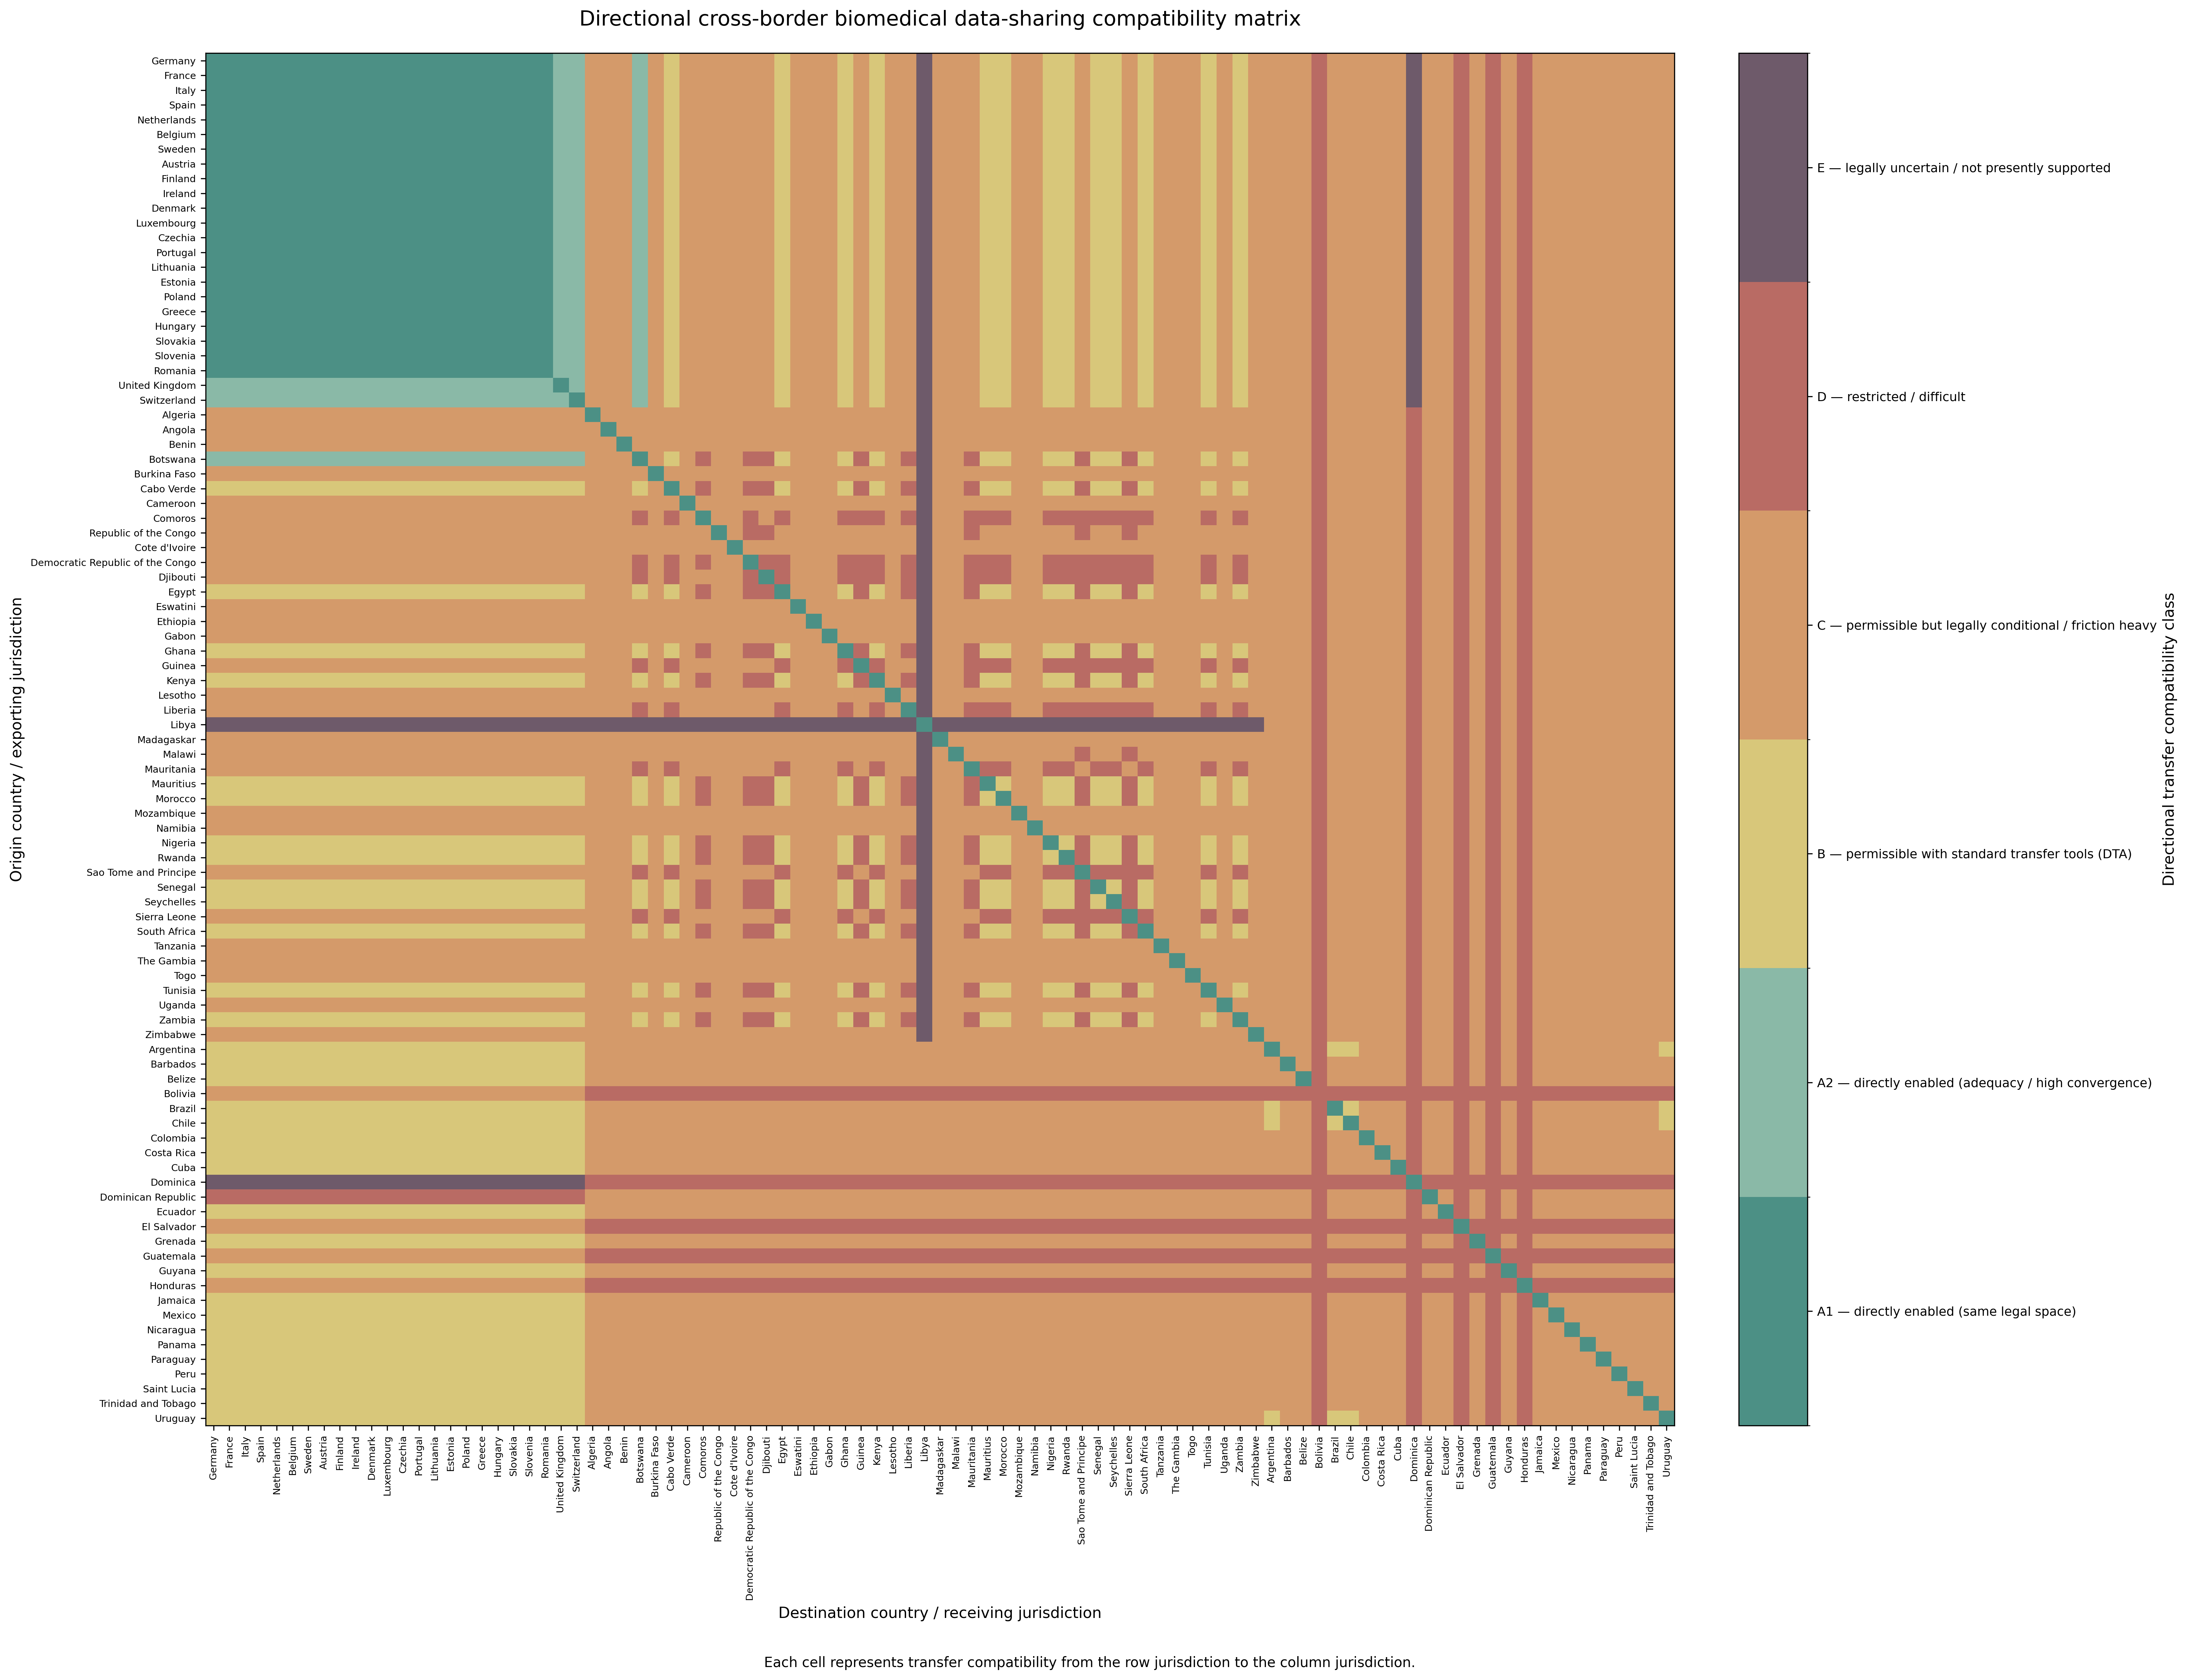

In [11]:
countries = list(numeric.index)

fig, ax = plt.subplots(figsize=(22, 17), dpi=300)

im = ax.imshow(
    numeric.values.astype(float),
    cmap=CMAP,
    norm=NORM,
    interpolation="none",
    aspect="auto",
)

ax.set_xticks(range(len(countries)))
ax.set_yticks(range(len(countries)))
ax.set_xticklabels(countries, rotation=90, fontsize=7)
ax.set_yticklabels(countries, fontsize=7)

add_category_colorbar(fig, ax, im)

ax.set_title("Directional cross-border biomedical data-sharing compatibility matrix", fontsize=15, pad=20)
ax.set_xlabel("Destination country / receiving jurisdiction", fontsize=11)
ax.set_ylabel("Origin country / exporting jurisdiction", fontsize=11)

fig.text(
    0.5, 0.01,
    "Each cell represents transfer compatibility from the row jurisdiction to the column jurisdiction.",
    ha="center", va="bottom", fontsize=10
)

fig.tight_layout(rect=[0, 0.03, 1, 1])
savefig(fig, "01_directional_matrix_custom_palette")
plt.show()


## 2. Per-country stacked distribution plot

This plot summarizes each origin/exporting jurisdiction by the distribution of its outgoing transfer classes. Self-transfers are excluded.


In [12]:
rows = []
for country in df_no_self.index:
    values = pd.Series(df_no_self.loc[country].values).dropna()
    freq = values.value_counts(normalize=True).reindex(CATEGORY_ORDER).fillna(0)
    rows.append(freq)

outgoing_dist = pd.DataFrame(rows, index=df_no_self.index)
outgoing_dist = outgoing_dist.sort_values(by="A1", ascending=False)

countries_sorted = outgoing_dist.index.tolist()
y_pos = np.arange(len(countries_sorted))

fig_height = max(10, len(countries_sorted) * 0.8)
fig, ax = plt.subplots(figsize=(12, fig_height), dpi=300)

left = np.zeros(len(countries_sorted))
for category in CATEGORY_ORDER:
    vals = outgoing_dist[category].values
    ax.barh(y_pos, vals, left=left, height=0.6, color=PALETTE[category], label=category)
    left += vals

ax.set_yticks(y_pos)
ax.set_yticklabels(countries_sorted, fontsize=10.5)
ax.set_xlabel("Proportion of outgoing transfers", fontsize=11)
ax.set_ylabel("Country / origin jurisdiction", fontsize=11)
ax.set_title("Per-country distribution of outgoing transfer compatibility classes", fontsize=14, pad=14)
ax.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
savefig(fig, "02_per_country_outgoing_distribution")
plt.show()


## 3. Import and export mode world maps

These maps summarize each country using the modal compatibility class.

The **export mode** is the most common class across each row, after removing self-transfers.

The **import mode** is the most common class across each column, after removing self-transfers.

This section requires a country boundary shapefile or GeoJSON. Natural Earth Admin 0 countries is recommended. If no map file is available, the notebook will print the modal table and skip map rendering.


In [13]:
# Install geopandas locally if needed:
# pip install geopandas

WORLD_FILE = Path("ne_110m_admin_0_countries.shp")  # Change this path to your Natural Earth .shp or .geojson file.

NAME_TO_NATURAL_EARTH = {
    "United Kingdom": "United Kingdom",
    "United States": "United States of America",
    "USA": "United States of America",
    "Czechia": "Czechia",
    "Democratic Republic of the Congo": "Dem. Rep. Congo",
    "Republic of the Congo": "Congo",
    "Côte d’Ivoire": "Côte d'Ivoire",
    "Cote d'Ivoire": "Côte d'Ivoire",
    "Eswatini": "eSwatini",
    "South Sudan": "S. Sudan",
    "Central African Republic": "Central African Rep.",
}

export_mode = df_no_self.apply(lambda row: mode_or_nan(row.values), axis=1)
import_mode = df_no_self.apply(lambda col: mode_or_nan(col.values), axis=0)

mode_df = pd.DataFrame({
    "country": df_no_self.index,
    "export_mode": export_mode.values,
    "import_mode": import_mode.reindex(df_no_self.index).values,
})
mode_df["map_name"] = mode_df["country"].replace(NAME_TO_NATURAL_EARTH)

mode_df.head()


,country,export_mode,import_mode,map_name
0,Germany,C,B,Germany
1,France,C,B,France
2,Italy,C,B,Italy
3,Spain,C,B,Spain
4,Netherlands,C,B,Netherlands


In [14]:
def try_load_world_map(world_file):
    try:
        import geopandas as gpd
    except ImportError:
        print("geopandas is not installed. Map rendering skipped.")
        return None

    if not world_file.exists():
        print(f"World map file not found: {world_file}. Map rendering skipped.")
        return None

    world = gpd.read_file(world_file)

    candidate_name_columns = ["NAME", "ADMIN", "name", "Name"]
    name_col = next((c for c in candidate_name_columns if c in world.columns), None)
    if name_col is None:
        raise ValueError(f"Could not identify a country-name column. Available columns: {list(world.columns)}")

    world = world.rename(columns={name_col: "map_name"})
    return world


world = try_load_world_map(WORLD_FILE)

if world is not None:
    merged = world.merge(mode_df, on="map_name", how="left")

    unmatched = sorted(set(mode_df["map_name"]) - set(world["map_name"]))
    print("Unmatched matrix countries requiring name harmonization:")
    print(unmatched)
else:
    merged = None
    print(mode_df)


World map file not found: ne_110m_admin_0_countries.shp. Map rendering skipped.
                country export_mode import_mode             map_name
0               Germany           C           B              Germany
1                France           C           B               France
2                 Italy           C           B                Italy
3                 Spain           C           B                Spain
4           Netherlands           C           B          Netherlands
..                  ...         ...         ...                  ...
88             Paraguay           C           C             Paraguay
89                 Peru           C           C                 Peru
90          Saint Lucia           C           C          Saint Lucia
91  Trinidad and Tobago           C           C  Trinidad and Tobago
92              Uruguay           C           C              Uruguay

[93 rows x 4 columns]


In [15]:
legend_handles = [
    mpatches.Patch(color=PALETTE[c], label=CATEGORY_LABELS[i])
    for i, c in enumerate(CATEGORY_ORDER)
]

def plot_mode_map(column, title, outfile_base):
    if merged is None:
        print(f"Skipping {title}: no world map file was loaded.")
        return

    colors = merged[column].map(PALETTE).fillna("#E6E6E6")

    fig, ax = plt.subplots(figsize=(14, 8), dpi=300)
    merged.plot(color=colors, ax=ax, edgecolor="white", linewidth=0.35)

    ax.set_title(title, fontsize=15, pad=14)
    ax.axis("off")

    ax.legend(
        handles=legend_handles,
        title="Dominant compatibility class",
        loc="lower left",
        frameon=True,
        fontsize=8,
        title_fontsize=9,
    )

    fig.tight_layout()
    savefig(fig, outfile_base)
    plt.show()


plot_mode_map("import_mode", "Dominant import compatibility class by receiving jurisdiction", "03a_world_map_import_mode")
plot_mode_map("export_mode", "Dominant export compatibility class by exporting jurisdiction", "03b_world_map_export_mode")


Skipping Dominant import compatibility class by receiving jurisdiction: no world map file was loaded.
Skipping Dominant export compatibility class by exporting jurisdiction: no world map file was loaded.


## 4. Asymmetry matrix

The asymmetry matrix quantifies directional imbalance:

\[
\Delta_{ij} = f(i \rightarrow j) - f(j \rightarrow i)
\]

where A1 = 0 and E = 5. Positive values mean that the transfer from the row country to the column country is more difficult than the reverse direction. Negative values mean it is easier than the reverse direction.


In [16]:
asymmetry = numeric - numeric.T
np.fill_diagonal(asymmetry.values, np.nan)
np.fill_diagonal(df_no_self.values, np.nan)

vmax = np.nanmax(np.abs(asymmetry.values.astype(float)))
norm_asym = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, ax = plt.subplots(figsize=(20, 16), dpi=300)
im = ax.imshow(asymmetry.values.astype(float), cmap="RdBu_r", norm=norm_asym, interpolation="none", aspect="auto")

ax.set_xticks(range(len(asymmetry.columns)))
ax.set_yticks(range(len(asymmetry.index)))
ax.set_xticklabels(asymmetry.columns, rotation=90, fontsize=7)
ax.set_yticklabels(asymmetry.index, fontsize=7)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Directional asymmetry in legal friction\n(row → column minus column → row)", fontsize=10)

ax.set_title("Directional asymmetry matrix", fontsize=15, pad=18)
ax.set_xlabel("Destination jurisdiction", fontsize=11)
ax.set_ylabel("Origin jurisdiction", fontsize=11)

fig.tight_layout()
savefig(fig, "04_asymmetry_matrix")
plt.show()


ValueError: underlying array is read-only

## 5. Directed network analysis

This representation treats countries as nodes and viable transfer relationships as directed edges. The default threshold keeps A1, A2, and B relationships only. This avoids the visual “hairball” produced by including every weak or unsupported relation.


In [17]:
# Install networkx locally if needed:
# pip install networkx

try:
    import networkx as nx
    HAS_NETWORKX = True
except ImportError:
    HAS_NETWORKX = False
    print("networkx is not installed. Network section skipped.")


,country,out_strength,in_strength,betweenness
0,Germany,82.0,102.0,0.001394
12,Czechia,82.0,102.0,0.001394
1,France,82.0,102.0,0.001394
21,Romania,82.0,102.0,0.001394
19,Slovakia,82.0,102.0,0.001394
18,Hungary,82.0,102.0,0.001394
17,Greece,82.0,102.0,0.001394
16,Poland,82.0,102.0,0.001394
15,Estonia,82.0,102.0,0.001394
14,Lithuania,82.0,102.0,0.001394


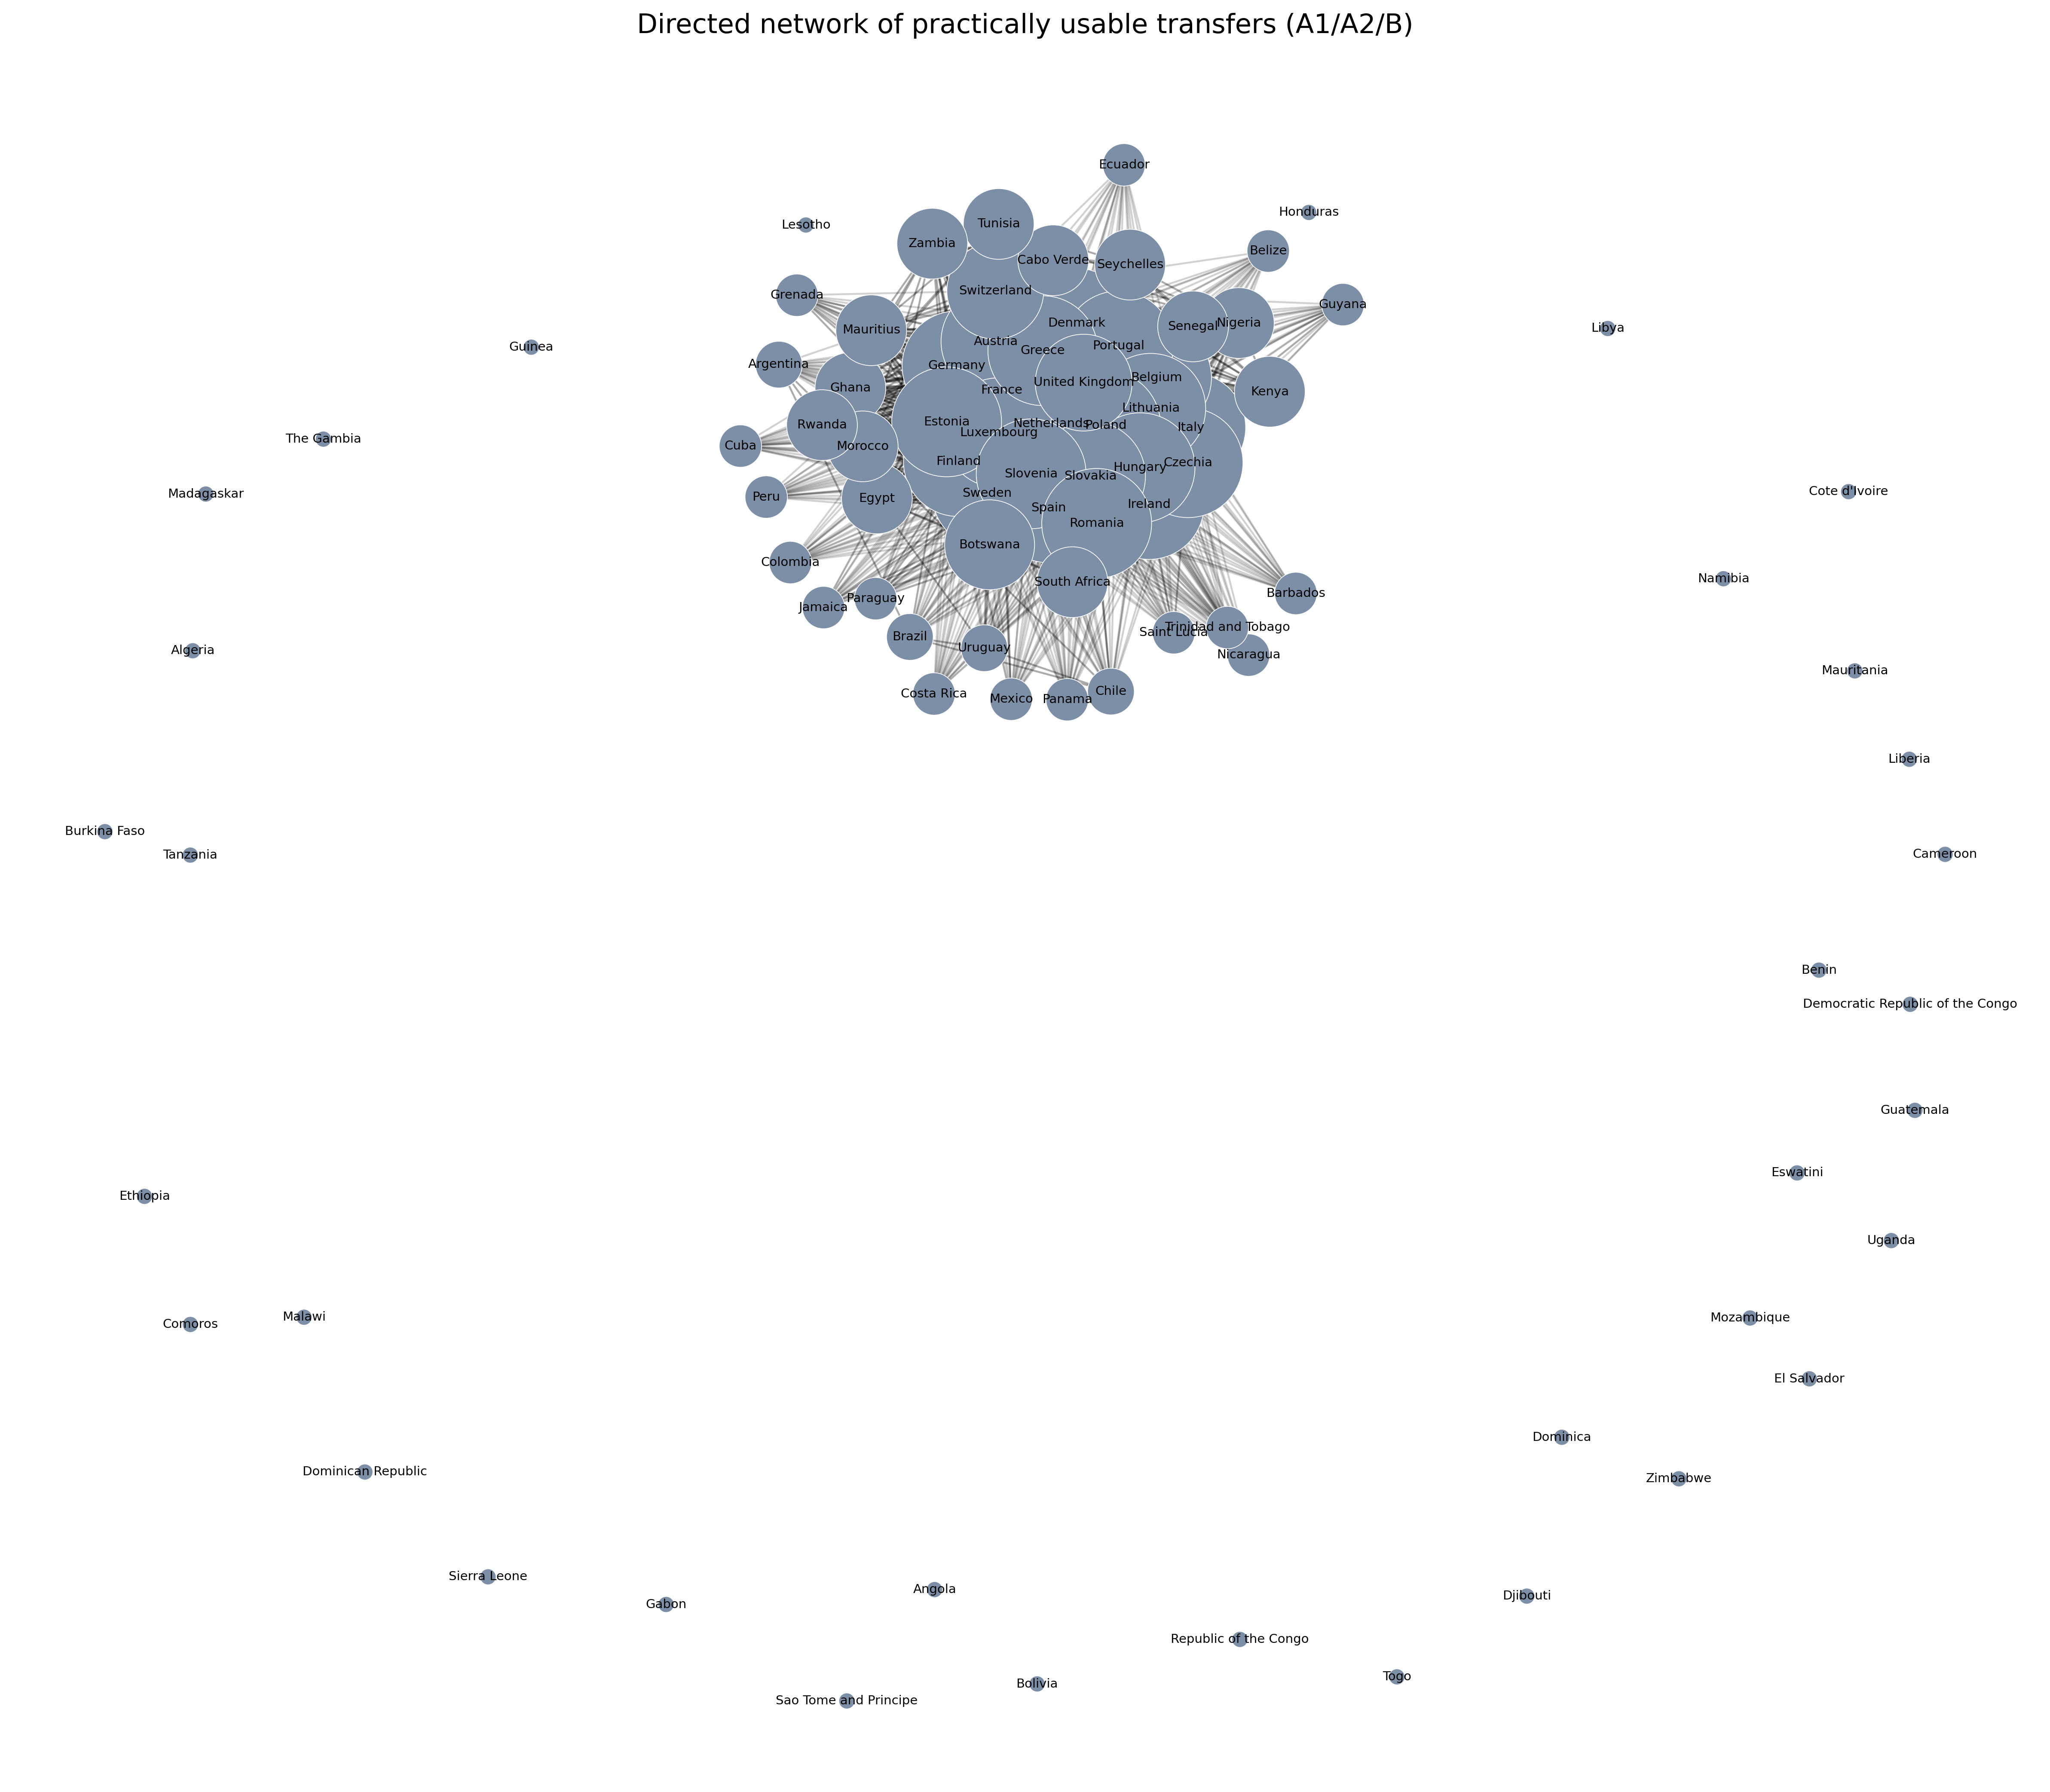

In [18]:
if HAS_NETWORKX:
    THRESHOLD_MAX_VALUE = CATEGORY_TO_VALUE["B"]  # keep A1, A2, B

    G = nx.DiGraph()
    for c in numeric_no_self.index:
        G.add_node(c)

    for origin in numeric_no_self.index:
        for dest in numeric_no_self.columns:
            val = numeric_no_self.loc[origin, dest]
            if pd.notna(val) and val <= THRESHOLD_MAX_VALUE:
                # Stronger edge for easier transfer.
                weight = (THRESHOLD_MAX_VALUE + 1) - val
                G.add_edge(origin, dest, weight=float(weight), category=VALUE_TO_CATEGORY[int(val)])

    out_strength = dict(G.out_degree(weight="weight"))
    in_strength = dict(G.in_degree(weight="weight"))
    betweenness = nx.betweenness_centrality(G, weight=None, normalized=True)

    centrality_df = pd.DataFrame({
        "country": list(G.nodes),
        "out_strength": [out_strength.get(n, 0) for n in G.nodes],
        "in_strength": [in_strength.get(n, 0) for n in G.nodes],
        "betweenness": [betweenness.get(n, 0) for n in G.nodes],
    }).sort_values("out_strength", ascending=False)

    display(centrality_df.head(15))

    # Stable spring layout for publication-like visualization.
    pos = nx.spring_layout(G, k=0.8, seed=7, weight="weight")

    fig, ax = plt.subplots(figsize=(16, 14), dpi=300)

    edge_widths = [0.25 + 0.8 * G[u][v]["weight"] for u, v in G.edges]
    node_sizes = [80 + 20 * (out_strength.get(n, 0) + in_strength.get(n, 0)) for n in G.nodes]

    nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths, alpha=0.18, arrows=True, arrowsize=6)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color="#7D8FA6", edgecolors="white", linewidths=0.4)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7)

    ax.set_title("Directed network of practically usable transfers (A1/A2/B)", fontsize=15, pad=15)
    ax.axis("off")

    fig.tight_layout()
    savefig(fig, "05_directed_network_thresholded")
    plt.show()


## 6. Country legal-profile embedding

Each country can be treated as a vector of legal friction values toward all destinations. Dimensionality reduction then reveals countries with similar export profiles.

This section uses PCA by default because it is interpretable and requires only scikit-learn.


In [19]:
# Install scikit-learn locally if needed:
# pip install scikit-learn

try:
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False
    print("scikit-learn is not installed. PCA embedding skipped.")


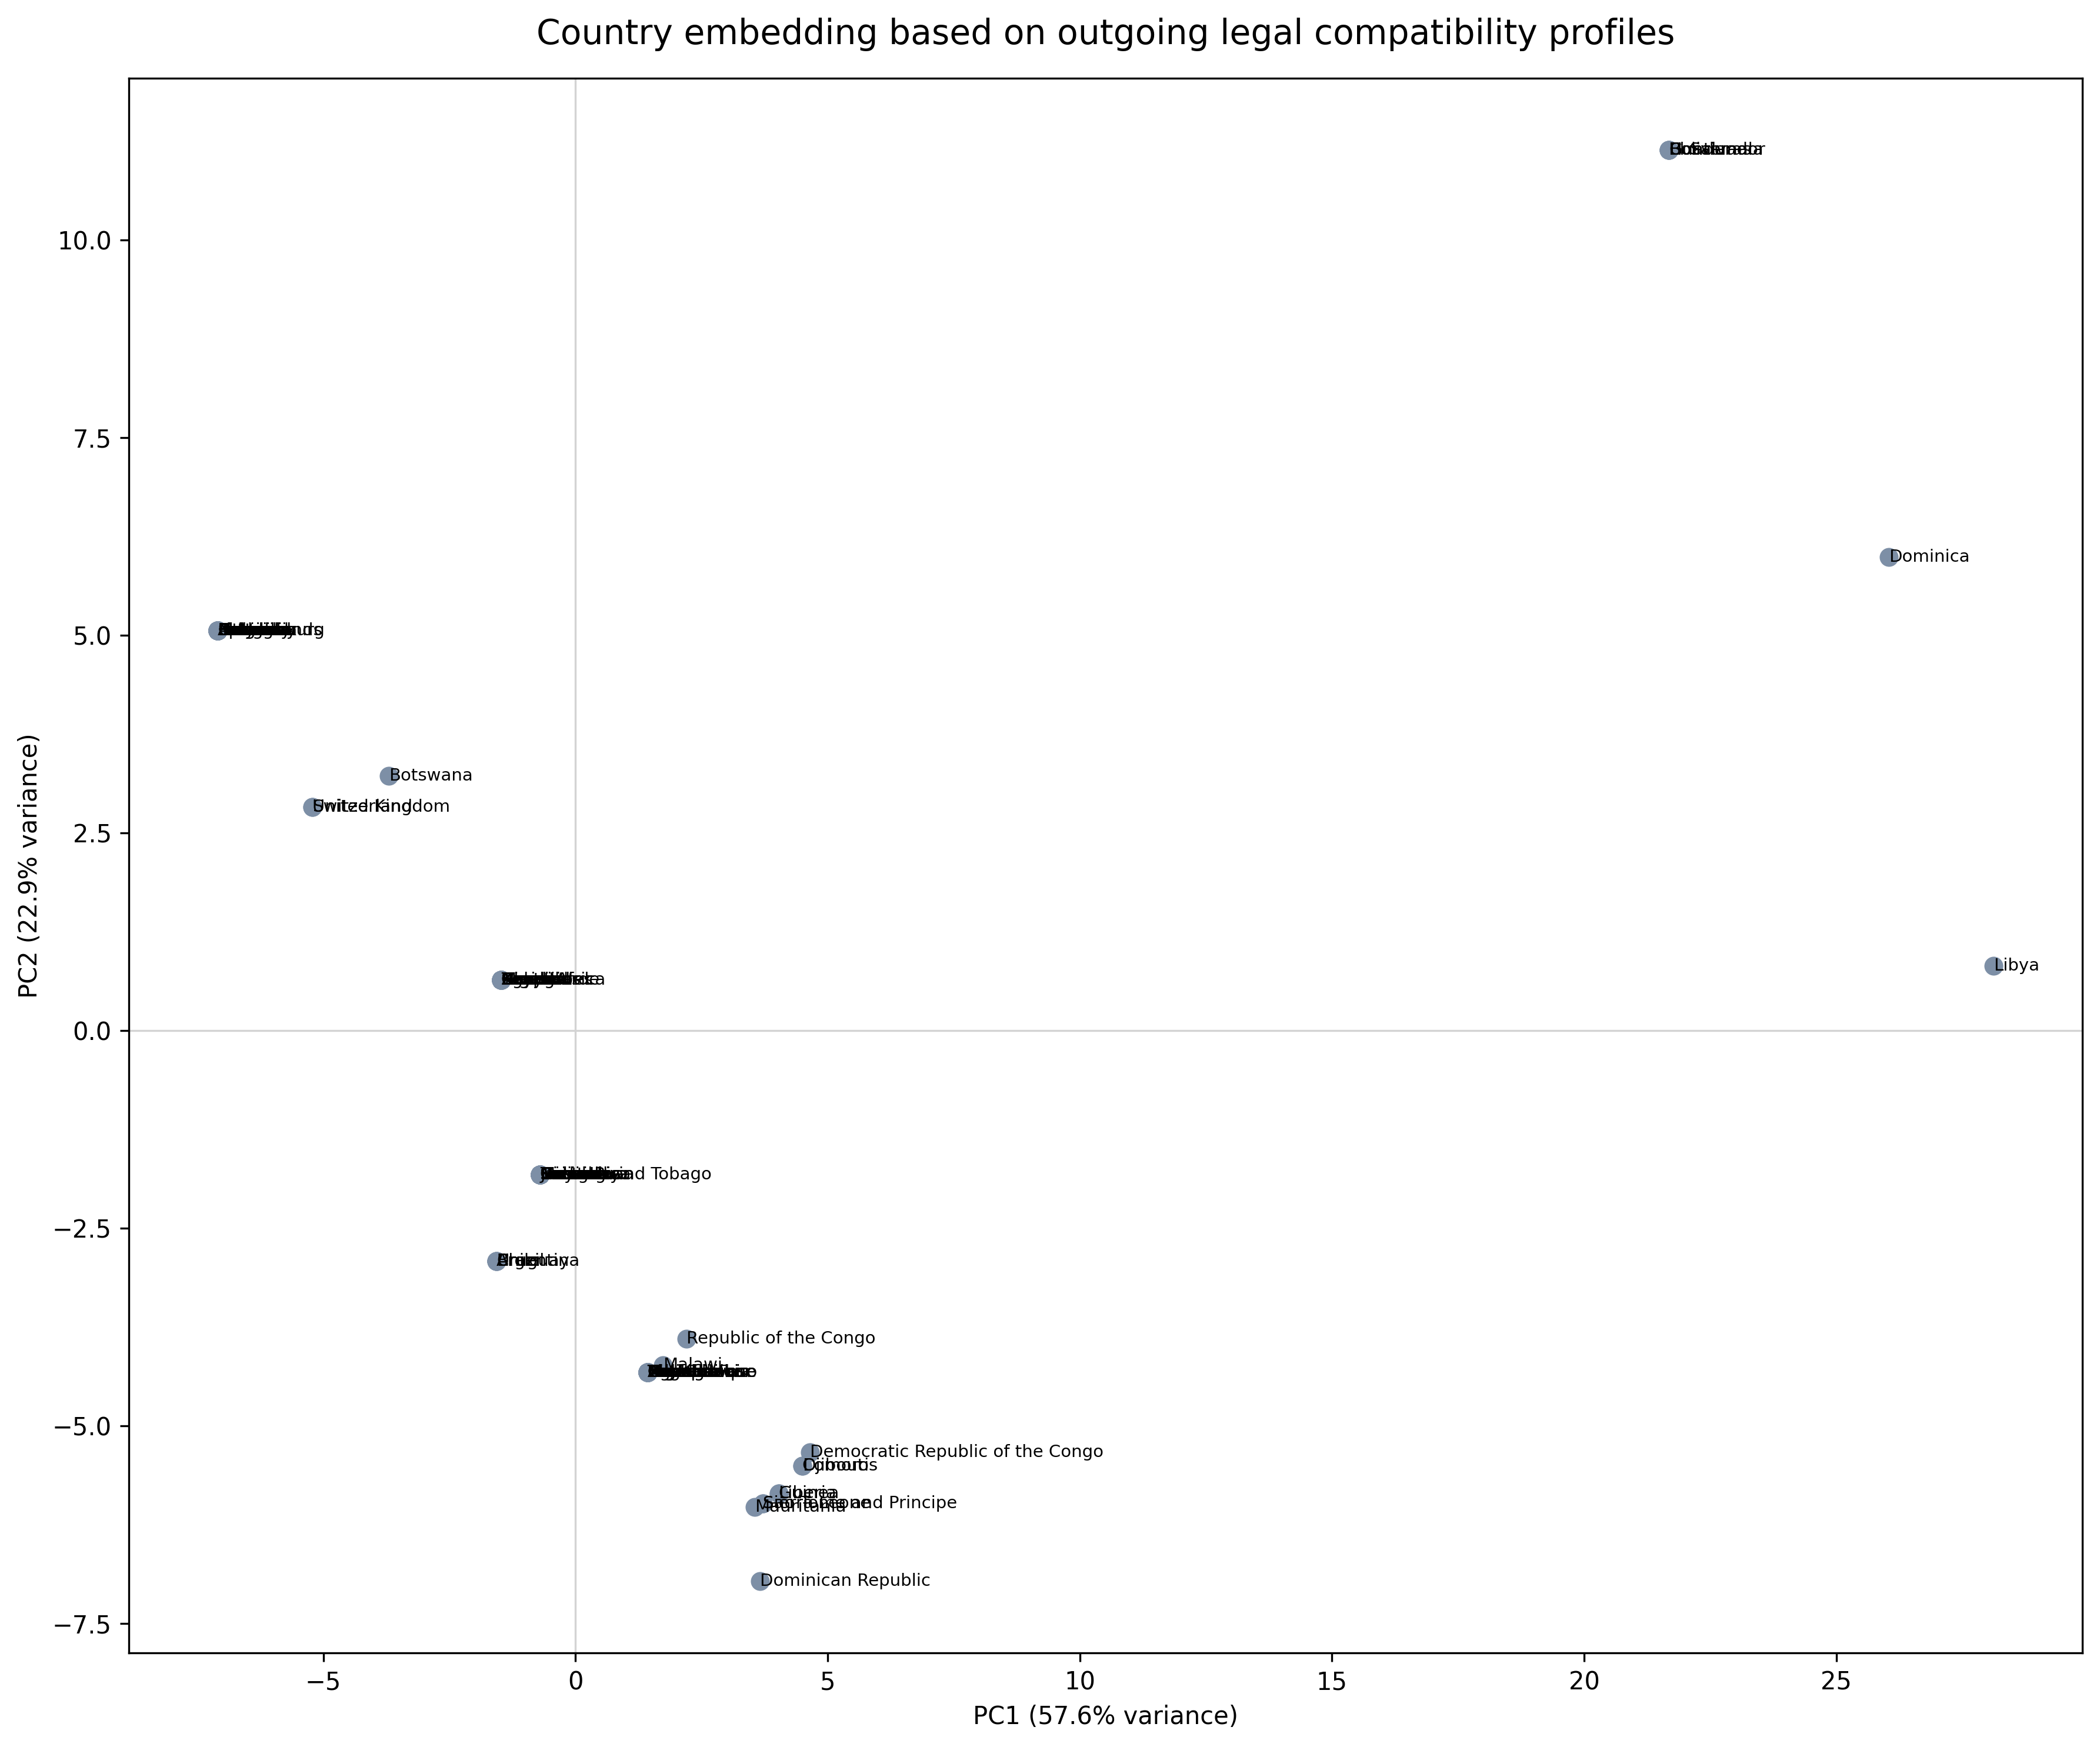

In [20]:
if HAS_SKLEARN:
    # Fill missing values with column medians, then global median if needed.
    X = numeric_no_self.copy().astype(float)
    X = X.apply(lambda col: col.fillna(col.median()), axis=0)
    X = X.fillna(np.nanmedian(X.values))

    X_scaled = StandardScaler().fit_transform(X)

    pca = PCA(n_components=2, random_state=7)
    coords = pca.fit_transform(X_scaled)

    pca_df = pd.DataFrame({
        "country": X.index,
        "PC1": coords[:, 0],
        "PC2": coords[:, 1],
    })

    fig, ax = plt.subplots(figsize=(12, 10), dpi=300)
    ax.scatter(pca_df["PC1"], pca_df["PC2"], s=45, color="#7D8FA6")

    for _, row in pca_df.iterrows():
        ax.text(row["PC1"], row["PC2"], row["country"], fontsize=7, ha="left", va="center")

    ax.axhline(0, color="lightgray", linewidth=0.8)
    ax.axvline(0, color="lightgray", linewidth=0.8)

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
    ax.set_title("Country embedding based on outgoing legal compatibility profiles", fontsize=14, pad=14)

    fig.tight_layout()
    savefig(fig, "06_country_profile_pca_embedding")
    plt.show()


## 7. Entropy / diversity profile and map

Mode maps are easy to interpret but compress information. Entropy quantifies how heterogeneous a country’s compatibility profile is.

Low entropy means the country has a relatively uniform profile. High entropy means the country has a mixed profile across legal classes.


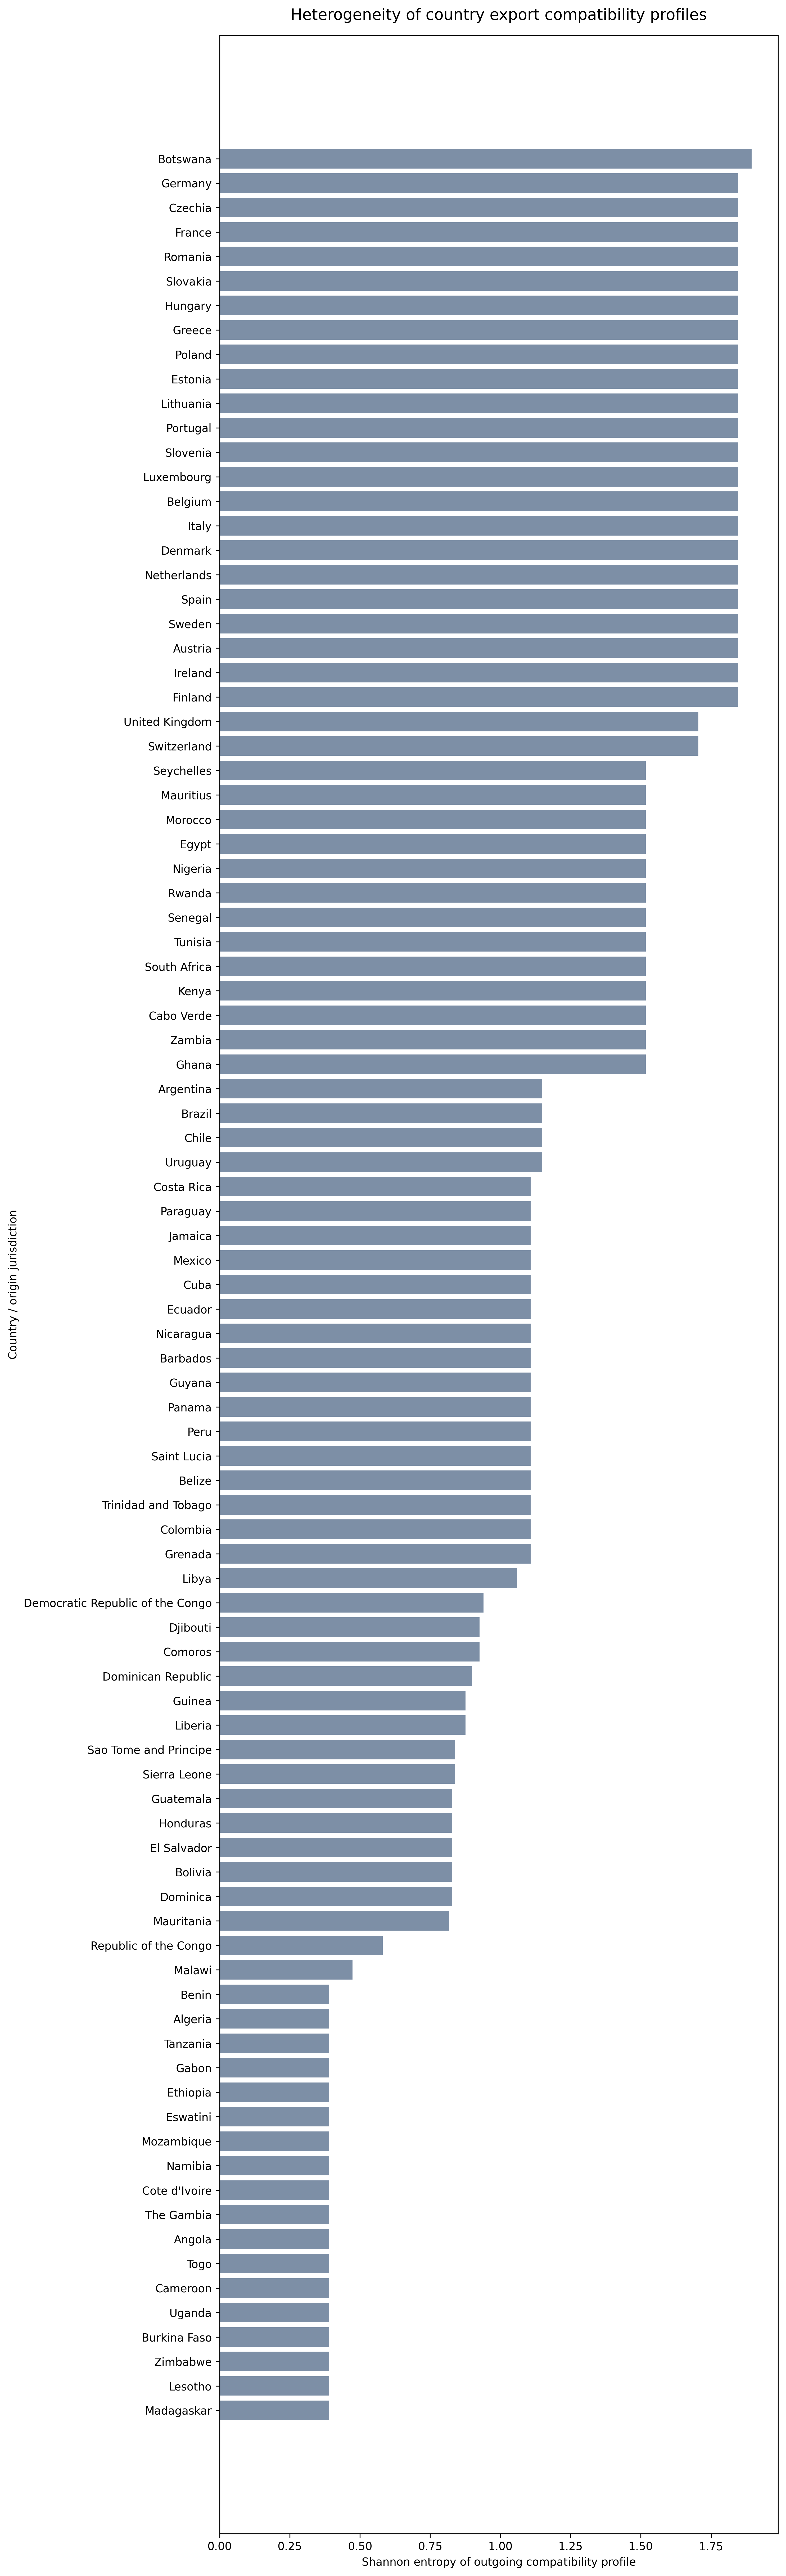

In [21]:
def shannon_entropy(categories):
    values = pd.Series(categories).dropna()
    if values.empty:
        return np.nan
    p = values.value_counts(normalize=True)
    return float(-(p * np.log2(p)).sum())


entropy_df = pd.DataFrame({
    "country": df_no_self.index,
    "export_entropy": df_no_self.apply(lambda row: shannon_entropy(row.values), axis=1).values,
    "import_entropy": df_no_self.apply(lambda col: shannon_entropy(col.values), axis=0).reindex(df_no_self.index).values,
})

entropy_sorted = entropy_df.sort_values("export_entropy", ascending=False)

fig, ax = plt.subplots(figsize=(10, max(8, len(entropy_sorted) * 0.35)), dpi=300)
ax.barh(entropy_sorted["country"], entropy_sorted["export_entropy"], color="#7D8FA6")
ax.invert_yaxis()
ax.set_xlabel("Shannon entropy of outgoing compatibility profile")
ax.set_ylabel("Country / origin jurisdiction")
ax.set_title("Heterogeneity of country export compatibility profiles", fontsize=14, pad=14)

fig.tight_layout()
savefig(fig, "07a_export_entropy_barplot")
plt.show()


In [22]:
def plot_entropy_map(column, title, outfile_base):
    if merged is None:
        print(f"Skipping {title}: no world map file was loaded.")
        return

    entropy_map_df = entropy_df.copy()
    entropy_map_df["map_name"] = entropy_map_df["country"].replace(NAME_TO_NATURAL_EARTH)

    map_merged = world.merge(entropy_map_df, on="map_name", how="left")

    fig, ax = plt.subplots(figsize=(14, 8), dpi=300)
    map_merged.plot(column=column, ax=ax, legend=True, cmap="magma", edgecolor="white", linewidth=0.35)

    ax.set_title(title, fontsize=15, pad=14)
    ax.axis("off")

    fig.tight_layout()
    savefig(fig, outfile_base)
    plt.show()


plot_entropy_map("import_entropy", "Import-profile entropy by receiving jurisdiction", "07b_world_map_import_entropy")
plot_entropy_map("export_entropy", "Export-profile entropy by exporting jurisdiction", "07c_world_map_export_entropy")


Skipping Import-profile entropy by receiving jurisdiction: no world map file was loaded.
Skipping Export-profile entropy by exporting jurisdiction: no world map file was loaded.


## 8. Sankey / alluvial-style summary

This summary aggregates directed relationships by pairing each origin country’s export-mode class with the actual compatibility classes of its outgoing transfers. It provides a compact overview of how country-level profiles distribute into transfer-level outcomes.

If Plotly is available, an interactive Sankey plot is generated. Otherwise, a static heatmap fallback is produced.


In [ ]:
# Prepare transfer-level summary.
records = []
for origin in df_no_self.index:
    origin_mode = export_mode.loc[origin]
    for dest in df_no_self.columns:
        cls = df_no_self.loc[origin, dest]
        if pd.notna(cls):
            records.append({
                "origin": origin,
                "destination": dest,
                "origin_export_mode": origin_mode,
                "transfer_class": cls,
            })

flow_df = pd.DataFrame(records)
flow_counts = (
    flow_df
    .groupby(["origin_export_mode", "transfer_class"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=CATEGORY_ORDER, columns=CATEGORY_ORDER, fill_value=0)
)

display(flow_counts)


In [ ]:
try:
    import plotly.graph_objects as go
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False
    print("plotly is not installed. Static heatmap fallback will be used.")

if HAS_PLOTLY:
    left_nodes = [f"Origin mode {c}" for c in CATEGORY_ORDER]
    right_nodes = [f"Transfer {c}" for c in CATEGORY_ORDER]
    labels = left_nodes + right_nodes

    sources, targets, values, colors = [], [], [], []
    for i, origin_class in enumerate(CATEGORY_ORDER):
        for j, transfer_class in enumerate(CATEGORY_ORDER):
            val = int(flow_counts.loc[origin_class, transfer_class])
            if val > 0:
                sources.append(i)
                targets.append(len(CATEGORY_ORDER) + j)
                values.append(val)
                colors.append(PALETTE[transfer_class])

    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=16,
            thickness=18,
            line=dict(color="black", width=0.3),
            label=labels,
            color=[PALETTE[c] for c in CATEGORY_ORDER] + [PALETTE[c] for c in CATEGORY_ORDER],
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors,
        )
    )])

    fig.update_layout(title_text="Alluvial summary of origin export mode to transfer-level class", font_size=11)
    fig.write_html(OUTDIR / "08_sankey_origin_mode_to_transfer_class.html")
    fig.show()
else:
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    im = ax.imshow(flow_counts.values, cmap=CMAP, aspect="auto")
    ax.set_xticks(range(len(CATEGORY_ORDER)))
    ax.set_yticks(range(len(CATEGORY_ORDER)))
    ax.set_xticklabels(CATEGORY_ORDER)
    ax.set_yticklabels(CATEGORY_ORDER)
    ax.set_xlabel("Transfer-level class")
    ax.set_ylabel("Origin export-mode class")
    ax.set_title("Static flow-summary heatmap")

    for i in range(flow_counts.shape[0]):
        for j in range(flow_counts.shape[1]):
            ax.text(j, i, int(flow_counts.iloc[i, j]), ha="center", va="center", fontsize=8)

    fig.tight_layout()
    savefig(fig, "08_static_flow_summary_heatmap")
    plt.show()


## 9. Region-aggregated block matrix

If a region mapping is available, the full country matrix can be aggregated into a small region-by-region matrix. The default mapping below is intentionally simple and should be edited to match the analytical regions used in the manuscript.


In [ ]:
# Edit or extend this dictionary to match your preferred regional classification.
EUROPE_UK = {
    "Germany","France","Italy","Spain","Netherlands","Belgium","Sweden","Austria","Finland",
    "Ireland","Denmark","Luxembourg","Czechia","Portugal","Lithuania","Estonia","Poland",
    "Greece","Hungary","Slovakia","Slovenia","Romania","United Kingdom","Switzerland",
    "Norway","Iceland","Croatia","Bulgaria","Latvia","Malta","Cyprus"
}

NORTH_AMERICA = {"United States", "United States of America", "Canada", "Mexico"}
LATIN_AMERICA = {
    "Argentina","Brazil","Chile","Colombia","Costa Rica","Peru","Uruguay","Ecuador",
    "Bolivia","Paraguay","Venezuela","Panama","Guatemala","Honduras","Nicaragua",
    "El Salvador","Dominican Republic"
}

def infer_region(country):
    if country in EUROPE_UK:
        return "Europe/UK"
    if country in NORTH_AMERICA:
        return "North America"
    if country in LATIN_AMERICA:
        return "Latin America"
    return "Africa / other"

region_map = {country: infer_region(country) for country in df_no_self.index}
regions = sorted(set(region_map.values()))

region_numeric = numeric_no_self.copy()
region_records = []
for origin_region in regions:
    origin_countries = [c for c in region_numeric.index if region_map[c] == origin_region]
    for dest_region in regions:
        dest_countries = [c for c in region_numeric.columns if region_map[c] == dest_region]
        vals = region_numeric.loc[origin_countries, dest_countries].values.flatten()
        vals = vals[~np.isnan(vals.astype(float))]
        mean_val = np.nan if len(vals) == 0 else float(np.mean(vals))
        mode_val = np.nan if len(vals) == 0 else int(pd.Series(vals).mode().iloc[0])
        region_records.append({
            "origin_region": origin_region,
            "destination_region": dest_region,
            "mean_friction": mean_val,
            "mode_value": mode_val,
            "mode_class": VALUE_TO_CATEGORY.get(mode_val, np.nan),
        })

region_df = pd.DataFrame(region_records)
display(region_df)


In [ ]:
block = region_df.pivot(index="origin_region", columns="destination_region", values="mean_friction").loc[regions, regions]

fig, ax = plt.subplots(figsize=(8, 7), dpi=300)
im = ax.imshow(block.values.astype(float), cmap=CMAP, norm=NORM, interpolation="none", aspect="equal")

ax.set_xticks(range(len(regions)))
ax.set_yticks(range(len(regions)))
ax.set_xticklabels(regions, rotation=45, ha="right")
ax.set_yticklabels(regions)

for i in range(len(regions)):
    for j in range(len(regions)):
        val = block.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)

add_category_colorbar(fig, ax, im, label="Mean legal friction across directed country pairs")
ax.set_title("Region-aggregated mean transfer friction", fontsize=14, pad=14)
ax.set_xlabel("Destination region")
ax.set_ylabel("Origin region")

fig.tight_layout()
savefig(fig, "09_region_aggregated_block_matrix")
plt.show()


## 10. Parallel-coordinate country profiles

This plot shows each country’s outgoing profile as a six-dimensional vector: the proportion of A1, A2, B, C, D, and E outgoing transfers.


In [ ]:
parallel_df = outgoing_dist.copy()
parallel_df["country"] = parallel_df.index

fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

x = np.arange(len(CATEGORY_ORDER))
for _, row in parallel_df.iterrows():
    y = [row[c] for c in CATEGORY_ORDER]
    ax.plot(x, y, color="#7D8FA6", alpha=0.35, linewidth=1)

# Overlay median profile.
median_profile = parallel_df[CATEGORY_ORDER].median()
ax.plot(x, median_profile.values, color="black", linewidth=2.5, label="Median country profile")

ax.set_xticks(x)
ax.set_xticklabels(CATEGORY_ORDER)
ax.set_ylabel("Proportion of outgoing transfers")
ax.set_xlabel("Compatibility class")
ax.set_title("Parallel-coordinate view of outgoing country profiles", fontsize=14, pad=14)
ax.legend(frameon=False)

fig.tight_layout()
savefig(fig, "10_parallel_coordinate_country_profiles")
plt.show()


## 11. Row-normalized country-by-class heatmap

This is a compact alternative to the stacked bar plot. Rows are countries and columns are legal classes. Each cell is the proportion of outgoing transfers from that country falling into the given class.


In [ ]:
heat = outgoing_dist[CATEGORY_ORDER].copy()

fig, ax = plt.subplots(figsize=(8, max(10, len(heat) * 0.35)), dpi=300)
im = ax.imshow(heat.values, cmap="Blues", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(CATEGORY_ORDER)))
ax.set_xticklabels(CATEGORY_ORDER)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index, fontsize=8)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Proportion of outgoing transfers", fontsize=10)

ax.set_xlabel("Compatibility class")
ax.set_ylabel("Origin jurisdiction")
ax.set_title("Row-normalized outgoing compatibility profile heatmap", fontsize=14, pad=14)

fig.tight_layout()
savefig(fig, "11_row_normalized_country_class_heatmap")
plt.show()


## 12. Inequality / Lorenz-style analysis of average legal friction

The mean legal-friction score for each origin country is computed using A1 = 0 through E = 5. The Lorenz-style curve shows whether legal friction is evenly distributed across countries or concentrated among a smaller set of jurisdictions.


In [ ]:
avg_export_friction = numeric_no_self.mean(axis=1, skipna=True).sort_values()
friction_df = pd.DataFrame({
    "country": avg_export_friction.index,
    "average_export_friction": avg_export_friction.values,
})

display(friction_df)

fig, ax = plt.subplots(figsize=(10, max(8, len(friction_df) * 0.3)), dpi=300)
ax.barh(friction_df["country"], friction_df["average_export_friction"], color="#7D8FA6")
ax.set_xlabel("Average outgoing legal friction (A1 = 0, E = 5)")
ax.set_ylabel("Country / origin jurisdiction")
ax.set_title("Average outgoing legal friction by country", fontsize=14, pad=14)

fig.tight_layout()
savefig(fig, "12a_average_export_friction_by_country")
plt.show()


In [ ]:
def gini_coefficient(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0 or np.all(x == 0):
        return np.nan
    x = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n


x = avg_export_friction.dropna().values
x_sorted = np.sort(x)
cum_friction = np.cumsum(x_sorted)
cum_friction_share = cum_friction / cum_friction[-1]
cum_country_share = np.arange(1, len(x_sorted) + 1) / len(x_sorted)

gini = gini_coefficient(x_sorted)

fig, ax = plt.subplots(figsize=(7, 7), dpi=300)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Equality line")
ax.plot(np.r_[0, cum_country_share], np.r_[0, cum_friction_share], color="#7D8FA6", linewidth=2.5)

ax.set_xlabel("Cumulative share of countries")
ax.set_ylabel("Cumulative share of average legal friction")
ax.set_title(f"Lorenz-style curve for outgoing legal friction\nGini coefficient = {gini:.3f}", fontsize=14, pad=14)
ax.legend(frameon=False)

fig.tight_layout()
savefig(fig, "12b_lorenz_curve_average_export_friction")
plt.show()


## Interpretation guide

The **directional matrix** is the most complete representation and should usually remain the primary figure. The **asymmetry matrix** is the most direct visualization of directional imbalance and is often the strongest additional analytical figure for a governance paper. The **network**, **PCA**, **entropy**, and **inequality** analyses provide complementary views of structure, clustering, heterogeneity, and concentration of legal friction.

The **mode maps** are visually intuitive but should be interpreted carefully because the mode compresses each country’s distribution into a single class. Entropy maps or stacked profiles preserve more information.
